# PolyCL demo


The three contrastive-view  are:

| Setting | View 1 | View 2 |
|---|---|---|
| None | Original | Original |
| Original + Mask | Original | Masked original |
| Enumeration + Mask | Enumerated SMILES | Masked original |

The quick demo trains only a few steps so it can show the complete pipeline.  
Set `QUICK_DEMO = False` for the configured full runs.


## 2. Load project code


In [1]:
from pathlib import Path

import pandas as pd
import torch
from transformers import AutoTokenizer

from src import pretrain
from src.augmentations import APPROACHES, make_contrastive_views
from src.dataloader import SmilesDataset, TgDataset
from src.train_tg import train_tg

ROOT = Path.cwd()



print("Device:", pretrain.DEVICE)
print("Approaches:", APPROACHES)


c:\Users\hozen\anaconda3\envs\polycl\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
Approaches: ('none', 'original_mask', 'enumeration_mask')


## 3. Dataset


In [2]:
pretrain_data = SmilesDataset(
    pretrain.CSV_PATH,
    pretrain.SMILES_COL,
)
tg_data = TgDataset(pretrain.CSV_PATH)

print("Pretraining rows:", len(pretrain_data))
print("Tg rows:", len(tg_data))
print("Example SMILES:", pretrain_data[0])
print("Example Tg (K):", tg_data[0][1])


Pretraining rows: 7372
Tg rows: 7372
Example SMILES: [*]Oc1c(C)cc([*])cc1C
Example Tg (K): 446.75


## 4. Show the three contrastive-view settings


In [3]:
torch.manual_seed(0)

tokenizer = AutoTokenizer.from_pretrained(
    pretrain.MODEL_NAME
)

sample = [pretrain_data[0]]

for approach in APPROACHES:
    (ids1, mask1), (ids2, mask2) = make_contrastive_views(
        smiles_batch=sample,
        tokenizer=tokenizer,
        approach=approach,
        max_length=pretrain.MAX_LENGTH,
        mask_probability=pretrain.MASK_PROB,
        device="cpu",
    )

    print("\n", approach)
    print("view 1:", tokenizer.convert_ids_to_tokens(ids1[0]))
    print("view 2:", tokenizer.convert_ids_to_tokens(ids2[0]))



 none
view 1: ['[CLS]', '▁', '[*]', 'O', 'c', '1', 'c', '(', 'C', ')', 'c', 'c', '(', '[*]', ')', 'c', 'c', '1', 'C', '[SEP]']
view 2: ['[CLS]', '▁', '[*]', 'O', 'c', '1', 'c', '(', 'C', ')', 'c', 'c', '(', '[*]', ')', 'c', 'c', '1', 'C', '[SEP]']

 original_mask
view 1: ['[CLS]', '▁', '[*]', 'O', 'c', '1', 'c', '(', 'C', ')', 'c', 'c', '(', '[*]', ')', 'c', 'c', '1', 'C', '[SEP]']
view 2: ['[CLS]', '▁', '[*]', 'O', 'c', '[MASK]', 'c', '(', 'C', '[MASK]', 'c', 'c', '(', '[*]', ')', 'c', 'c', '1', 'C', '[SEP]']

 enumeration_mask
view 1: ['[CLS]', '▁', 'c', '1', 'c', '(', 'c', 'c', '(', 'c', '(', 'c', '1', 'C', ')', 'O', '[*]', ')', 'C', ')', '[*]', '[SEP]']
view 2: ['[CLS]', '[MASK]', '[*]', 'O', 'c', '1', 'c', '(', 'C', ')', 'c', 'c', '(', '[*]', ')', 'c', 'c', '1', '[MASK]', '[SEP]']


## 5. Pretrain all three settings

`QUICK_DEMO=True` is only a smoke test.  
For an actual comparison, set it to `False`.


In [4]:
QUICK_DEMO = False

pretrain_steps = 2 if QUICK_DEMO else None
pretrain_epochs = 1 if QUICK_DEMO else pretrain.EPOCHS
suffix = "_demo" if QUICK_DEMO else ""

checkpoints = {}
histories = {}

for approach in APPROACHES:
    checkpoint = ROOT / "checkpoints" / f"polycl_{approach}{suffix}.pt"

    history = pretrain.pretrain(
        approach=approach,
        epochs=pretrain_epochs,
        max_steps=pretrain_steps,
        output_path=checkpoint,
    )

    checkpoints[approach] = checkpoint
    histories[approach] = history
    
    print(
        approach,
        "final contrastive loss:",
        round(history[-1], 4),
    )


Loading weights: 100%|██████████| 196/196 [00:00<00:00, 19603.76it/s]


none | epoch 1/10 | loss 0.0240
none | epoch 2/10 | loss 0.0060
none | epoch 3/10 | loss 0.0046
none | epoch 4/10 | loss 0.0051
none | epoch 5/10 | loss 0.0035
none | epoch 6/10 | loss 0.0038
none | epoch 7/10 | loss 0.0043
none | epoch 8/10 | loss 0.0028
none | epoch 9/10 | loss 0.0039
none | epoch 10/10 | loss 0.0019
none final contrastive loss: 0.0004


Loading weights: 100%|██████████| 196/196 [00:00<00:00, 12461.67it/s]


original_mask | epoch 1/10 | loss 0.0360
original_mask | epoch 2/10 | loss 0.0090
original_mask | epoch 3/10 | loss 0.0105
original_mask | epoch 4/10 | loss 0.0047
original_mask | epoch 5/10 | loss 0.0054
original_mask | epoch 6/10 | loss 0.0042
original_mask | epoch 7/10 | loss 0.0064
original_mask | epoch 8/10 | loss 0.0059
original_mask | epoch 9/10 | loss 0.0032
original_mask | epoch 10/10 | loss 0.0042
original_mask final contrastive loss: 0.0001


Loading weights: 100%|██████████| 196/196 [00:00<00:00, 8521.30it/s]


enumeration_mask | epoch 1/10 | loss 0.4195
enumeration_mask | epoch 2/10 | loss 0.0573
enumeration_mask | epoch 3/10 | loss 0.0339
enumeration_mask | epoch 4/10 | loss 0.0266
enumeration_mask | epoch 5/10 | loss 0.0243
enumeration_mask | epoch 6/10 | loss 0.0186
enumeration_mask | epoch 7/10 | loss 0.0205
enumeration_mask | epoch 8/10 | loss 0.0161
enumeration_mask | epoch 9/10 | loss 0.0136
enumeration_mask | epoch 10/10 | loss 0.0147
enumeration_mask final contrastive loss: 0.0119


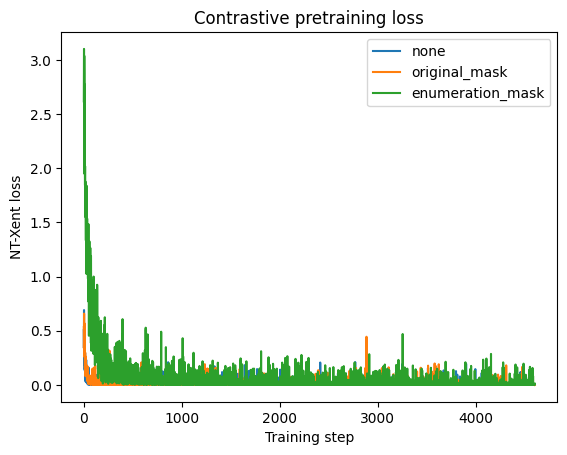

In [5]:
import matplotlib.pyplot as plt

for approach, history in histories.items():
    plt.plot(
        range(1, len(history) + 1),
        history,
        label=approach,
    )

plt.xlabel("Training step")
plt.ylabel("NT-Xent loss")
plt.title("Contrastive pretraining loss")
plt.legend()
plt.show()

## 6. Frozen-encoder Tg transfer learning

The encoder is frozen. Only the linear Tg prediction head is trained.

The quick demo limits training/evaluation batches so that the notebook finishes quickly.  
Those numbers are only a pipeline check, not benchmark results.


In [6]:
tg_epochs = 1 if QUICK_DEMO else 10
tg_train_steps = 10 if QUICK_DEMO else None
tg_test_steps = 5 if QUICK_DEMO else None

results = {}

for approach, checkpoint in checkpoints.items():
    metrics = train_tg(
        checkpoint_path=checkpoint,
        epochs=tg_epochs,
        max_train_steps=tg_train_steps,
        max_test_steps=tg_test_steps,
    )
    results[approach] = metrics

results = pd.DataFrame(results).T
results


Loading weights: 100%|██████████| 196/196 [00:00<00:00, 12250.16it/s]
c:\Users\hozen\Desktop\Projects\polycl_minimal_compare\downstream.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experime

Tg | epoch 1/10 | loss 0.3574
Tg | epoch 2/10 | loss 0.2289
Tg | epoch 3/10 | loss 0.2058
Tg | epoch 4/10 | loss 0.1951
Tg | epoch 5/10 | loss 0.1924
Tg | epoch 6/10 | loss 0.1878
Tg | epoch 7/10 | loss 0.1883
Tg | epoch 8/10 | loss 0.1836
Tg | epoch 9/10 | loss 0.1777
Tg | epoch 10/10 | loss 0.1770


Loading weights: 100%|██████████| 196/196 [00:00<00:00, 12248.70it/s]
c:\Users\hozen\Desktop\Projects\polycl_minimal_compare\downstream.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experime

Tg | epoch 1/10 | loss 0.3506
Tg | epoch 2/10 | loss 0.2290
Tg | epoch 3/10 | loss 0.2077
Tg | epoch 4/10 | loss 0.1966
Tg | epoch 5/10 | loss 0.1947
Tg | epoch 6/10 | loss 0.1897
Tg | epoch 7/10 | loss 0.1884
Tg | epoch 8/10 | loss 0.1855
Tg | epoch 9/10 | loss 0.1798
Tg | epoch 10/10 | loss 0.1795


Loading weights: 100%|██████████| 196/196 [00:00<00:00, 16333.22it/s]
c:\Users\hozen\Desktop\Projects\polycl_minimal_compare\downstream.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experime

Tg | epoch 1/10 | loss 0.2778
Tg | epoch 2/10 | loss 0.1978
Tg | epoch 3/10 | loss 0.1823
Tg | epoch 4/10 | loss 0.1776
Tg | epoch 5/10 | loss 0.1703
Tg | epoch 6/10 | loss 0.1706
Tg | epoch 7/10 | loss 0.1678
Tg | epoch 8/10 | loss 0.1659
Tg | epoch 9/10 | loss 0.1628
Tg | epoch 10/10 | loss 0.1598


,mae_k,rmse_k,r2
none,37.483185,49.330830,0.811855
original_mask,35.670662,47.255184,0.827355
enumeration_mask,34.045815,46.130138,0.835478


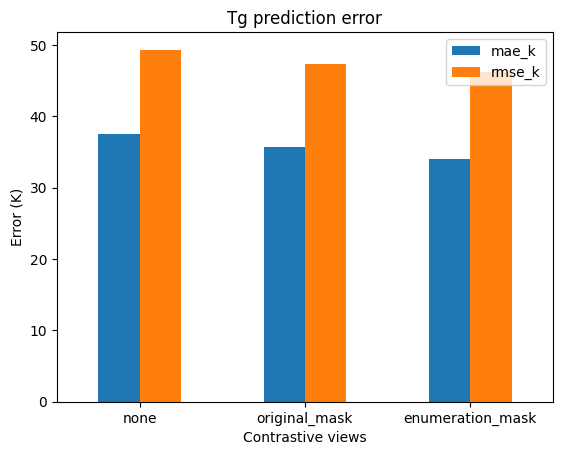

In [7]:
results[["mae_k", "rmse_k"]].plot(
    kind="bar",
)

plt.ylabel("Error (K)")
plt.xlabel("Contrastive views")
plt.title("Tg prediction error")
plt.xticks(rotation=0)
plt.show()

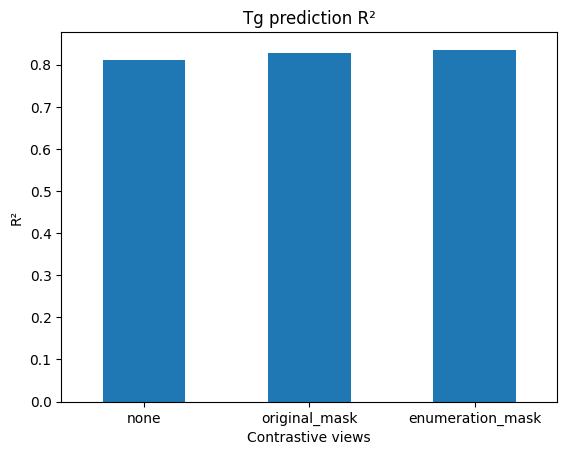

In [8]:
results["r2"].plot(
    kind="bar",
)

plt.ylabel("R²")
plt.xlabel("Contrastive views")
plt.title("Tg prediction R²")
plt.xticks(rotation=0)
plt.show()

In [9]:
display(
    results.rename(
        index={
            "none": "None",
            "original_mask": "Original + Mask",
            "enumeration_mask": "Enumeration + Mask",
        },
        columns={
            "mae_k": "MAE (K)",
            "rmse_k": "RMSE (K)",
            "r2": "R²",
        },
    ).round(3)
)

,MAE (K),RMSE (K),R²
None,37.483,49.331,0.812
Original + Mask,35.671,47.255,0.827
Enumeration + Mask,34.046,46.130,0.835


## 7. Full comparison

For meaningful results, change:

```python
QUICK_DEMO = False
```

and rerun sections 5 and 6. The same project code will then train the configured full pretraining and Tg-transfer runs.
